In [1]:
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt

events = pd.read_csv("events.dat", sep=" ")
events["chirp_mass"] = (events["mass_1"] * events["mass_2"])**0.6 / (events["mass_1"] + events["mass_2"])**0.2
events["mass_ratio"] = events["mass_2"] / events["mass_1"]

(array([3., 2., 1., 2., 1., 2., 5., 0., 4., 8.]),
 array([0.59238991, 0.63265505, 0.6729202 , 0.71318534, 0.75345049,
        0.79371563, 0.83398078, 0.87424592, 0.91451107, 0.95477621,
        0.99504135]),
 <BarContainer object of 10 artists>)

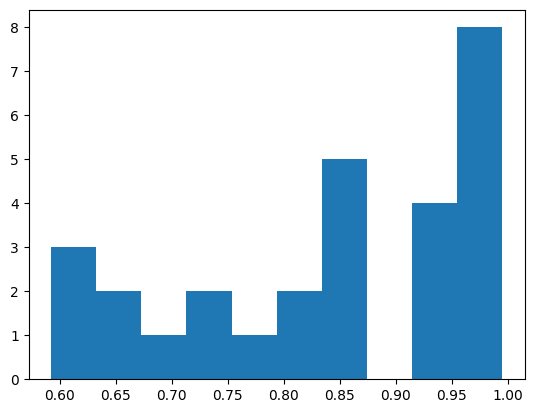

In [2]:
plt.hist(events["mass_ratio"])

In [4]:
def quantile_list(key):
    quantiles = np.zeros(events.shape[0])
    for j in range(3,events.shape[0]):
    
        posterior = np.load(f"gw_posteriors/source_{j}/posterior.npz")
    
        quantiles[j] = np.sum(posterior[key]<=events.loc[j, key]) / posterior[key].shape[0]

    return quantiles

quantiles = quantile_list("mass_1_source")
quantiles_detector = quantile_list("mass_1")
quantiles_chirp = quantile_list('chirp_mass')
quantiles_mass_ratio = quantile_list('mass_ratio')

Text(0.5, 0, 'chirp mass quantiles')

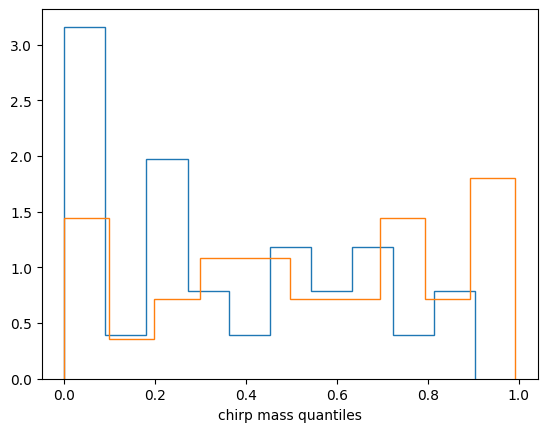

In [5]:

plt.hist(quantiles_chirp, histtype="step", density=True)
plt.hist(quantiles_mass_ratio, histtype="step", density=True)
plt.xlabel("chirp mass quantiles")

In [10]:
inds = quantiles_mass_ratio.argsort()
print(inds)

[ 0  1  2 21  7 20  9  5  8 14 19 18 23  3  6 24 22 15 11 26  4 17 16 25
 13 27 12 10]


In [11]:
np.sort(quantiles_mass_ratio)

array([0.        , 0.        , 0.        , 0.0583703 , 0.16018934,
       0.23655676, 0.28365223, 0.30250669, 0.30324124, 0.37346608,
       0.4090584 , 0.43233991, 0.4512565 , 0.50231839, 0.58851335,
       0.60719225, 0.66559668, 0.7175249 , 0.73245614, 0.76615606,
       0.78806444, 0.84764114, 0.89071797, 0.89294008, 0.91071036,
       0.92804112, 0.97027154, 0.99179347])

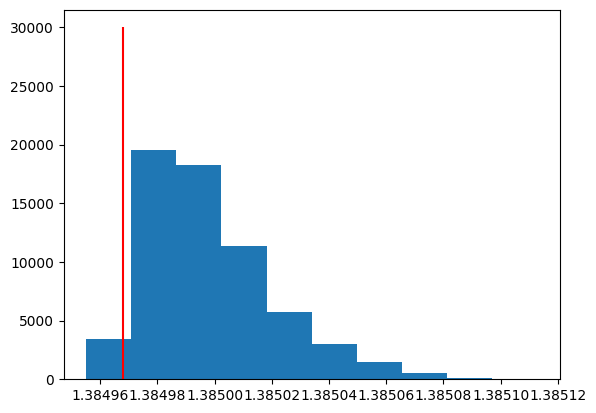

In [7]:
posterior = np.load("./gw_posteriors/source_42/posterior.npz")
plt.hist(posterior["chirp_mass"], density=True)
plt.vlines([events.loc[42, "chirp_mass"]], 0, 30_000, color="red")

In [19]:
from jesterTOV.inference.transforms import MultimessengerJesterTransform
from jesterTOV.utils import solar_mass_in_meter

from nmma.core.conversion import BNSEjectaFitting

/home/koehn1/miniconda3/envs/nmma_x_fiesta/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
mass_1 = events.loc[22, "mass_1_source"]
mass_2 = events.loc[22, "mass_2_source"]
radius_1 = events.loc[22, "radius_1"]
radius_2 = events.loc[22, "radius_2"]
compactness_1 = mass_1 / radius_1 * solar_mass_in_meter * 1e-3
compactness_2 = mass_2 / radius_2 * solar_mass_in_meter * 1e-3

log10_mej_dyn = np.log10(MultimessengerJesterTransform.dynamic_mass_fitting(mass_1, mass_2, compactness_1, compactness_2))

In [23]:
print(log10_mej_dyn, events.loc[22, "log10_mej_dyn"])

-2.235712866528109 -2.235648111224239


In [31]:
import jax

jax.random.uniform(jax.random.key(57191), shape=(10,), minval=1.32, maxval=1.2)

Array([1.32, 1.32, 1.32, 1.32, 1.32, 1.32, 1.32, 1.32, 1.32, 1.32],      dtype=float64)

In [22]:
events["mass_ratio"].min()

np.float64(0.7258205335293277)